# arXiv Topic Clustering

Unsupervised Machine Learning homework project for `VEMISAM255N/2025/26/2`.

The goal is to build a small research tool around recent machine learning and natural language processing papers from arXiv. The dominant task is unsupervised clustering: I will compare multiple clustering algorithms and document representations, then use the resulting topic structure for exploration and content-based paper recommendation.

## Block 1 - Data Acquisition

This block collects recent arXiv papers from `cs.LG` and `cs.CL`, restricted to the last 12 months. The fetched metadata is normalized into a tabular format and cached as parquet so later notebook runs do not need to query the live API again.

For the first implementation pass, the target dataset size is intentionally modest: roughly 2,000 papers. That is large enough for meaningful clustering while keeping API fetching and later embedding computation manageable for a time-sensitive homework workflow. To keep the later time-based analysis meaningful, the sample is fetched in monthly windows rather than taking only the newest 2,000 papers.

In [1]:
from __future__ import annotations

import math
from datetime import datetime, timedelta, timezone
from pathlib import Path

import arxiv
import pandas as pd

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

PAPERS_CACHE = DATA_DIR / "arxiv_papers_12mo_2000.parquet"
CATEGORIES = ["cs.LG", "cs.CL"]
TARGET_PAPERS = 2_000
LOOKBACK_DAYS = 365

END_DATE = datetime.now(timezone.utc)
START_DATE = END_DATE - timedelta(days=LOOKBACK_DAYS)

START_DATE.date(), END_DATE.date()

(datetime.date(2025, 5, 3), datetime.date(2026, 5, 3))

In [2]:
def arxiv_date(dt: datetime) -> str:
    """Format a datetime for arXiv's submittedDate search field."""
    return dt.strftime("%Y%m%d%H%M")


def build_query(categories: list[str], start_date: datetime, end_date: datetime) -> str:
    category_query = " OR ".join(f"cat:{category}" for category in categories)
    date_query = f"submittedDate:[{arxiv_date(start_date)} TO {arxiv_date(end_date)}]"
    return f"({category_query}) AND {date_query}"


def month_windows(start_date: datetime, end_date: datetime) -> list[tuple[datetime, datetime]]:
    starts = pd.date_range(
        start=start_date.date().replace(day=1),
        end=end_date.date(),
        freq="MS",
        tz="UTC",
    ).to_pydatetime()
    windows = []
    for window_start in starts:
        next_month = window_start + pd.DateOffset(months=1)
        clipped_start = max(window_start, start_date)
        clipped_end = min(next_month.to_pydatetime(), end_date)
        if clipped_start < clipped_end:
            windows.append((clipped_start, clipped_end))
    return windows


def paper_to_record(result: arxiv.Result) -> dict[str, object]:
    return {
        "arxiv_id": result.get_short_id(),
        "entry_id": result.entry_id,
        "title": " ".join(result.title.split()),
        "abstract": " ".join(result.summary.split()),
        "primary_category": result.primary_category,
        "categories": list(result.categories),
        "published": result.published,
        "updated": result.updated,
        "authors": [author.name for author in result.authors],
        "pdf_url": result.pdf_url,
    }


def fetch_arxiv_window(
    categories: list[str],
    start_date: datetime,
    end_date: datetime,
    max_results: int,
) -> pd.DataFrame:
    query = build_query(categories, start_date, end_date)
    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending,
    )
    client = arxiv.Client(page_size=100, delay_seconds=3, num_retries=5)

    records = [paper_to_record(result) for result in client.results(search)]
    return pd.DataFrame.from_records(records)


def fetch_arxiv_papers(
    categories: list[str],
    start_date: datetime,
    end_date: datetime,
    max_results: int,
) -> pd.DataFrame:
    windows = month_windows(start_date, end_date)
    max_per_window = math.ceil(max_results / len(windows))

    monthly_frames = []
    for window_start, window_end in windows:
        frame = fetch_arxiv_window(categories, window_start, window_end, max_per_window)
        print(f"{window_start:%Y-%m}: fetched {len(frame):>3} papers")
        monthly_frames.append(frame)

    papers = pd.concat(monthly_frames, ignore_index=True)
    if papers.empty:
        raise RuntimeError("The arXiv query returned no papers. Check API access and query syntax.")

    papers = (
        papers.drop_duplicates(subset="arxiv_id")
        .sort_values("published", ascending=False)
        .reset_index(drop=True)
    )
    papers["published_month"] = papers["published"].dt.to_period("M").astype(str)
    papers["abstract_length"] = papers["abstract"].str.split().str.len()
    return papers.head(max_results)


windows = month_windows(START_DATE, END_DATE)
query = build_query(CATEGORIES, windows[0][0], windows[0][1])
len(windows), query

(13,
 '(cat:cs.LG OR cat:cs.CL) AND submittedDate:[202505032057 TO 202506010000]')

In [3]:
if PAPERS_CACHE.exists():
    papers = pd.read_parquet(PAPERS_CACHE)
    source = "cache"
else:
    papers = fetch_arxiv_papers(CATEGORIES, START_DATE, END_DATE, TARGET_PAPERS)
    papers.to_parquet(PAPERS_CACHE, index=False)
    source = "arXiv API"

print(f"Loaded {len(papers):,} papers from {source}.")
print(f"Cache path: {PAPERS_CACHE}")
papers.head(3)

Loaded 1,848 papers from cache.
Cache path: data/arxiv_papers_12mo_2000.parquet


,arxiv_id,entry_id,title,abstract,primary_category,categories,published,updated,authors,pdf_url,published_month,abstract_length
0,2604.28186v1,http://arxiv.org/abs/2604.28186v1,Computing Equilibrium beyond Unilateral Deviation,"Most familiar equilibrium concepts, such as Nash and correlated equilibrium, guarantee only that no single player ca...",cs.GT,"[cs.GT, cs.AI, cs.CC, cs.LG, econ.TH]",2026-04-30 17:59:07+00:00,2026-04-30 17:59:07+00:00,"[Mingyang Liu, Gabriele Farina, Asuman Ozdaglar]",https://arxiv.org/pdf/2604.28186v1,2026-04,170
1,2604.28182v1,http://arxiv.org/abs/2604.28182v1,Exploration Hacking: Can LLMs Learn to Resist RL Training?,"Reinforcement learning (RL) has become essential to the post-training of large language models (LLMs) for reasoning,...",cs.LG,"[cs.LG, cs.CL]",2026-04-30 17:58:39+00:00,2026-04-30 17:58:39+00:00,"[Eyon Jang, Damon Falck, Joschka Braun, Nathalie Kirch, Achu Menon, Perusha Moodley, Scott Emmons, Roland S. Zimmerm...",https://arxiv.org/pdf/2604.28182v1,2026-04,176
2,2604.28181v1,http://arxiv.org/abs/2604.28181v1,Synthetic Computers at Scale for Long-Horizon Productivity Simulation,"Realistic long-horizon productivity work is strongly conditioned on user-specific computer environments, where much ...",cs.AI,"[cs.AI, cs.CL, cs.LG]",2026-04-30 17:58:02+00:00,2026-04-30 17:58:02+00:00,"[Tao Ge, Baolin Peng, Hao Cheng, Jianfeng Gao]",https://arxiv.org/pdf/2604.28181v1,2026-04,251


In [4]:
summary = {
    "papers": len(papers),
    "date_min": papers["published"].min().date(),
    "date_max": papers["published"].max().date(),
    "primary_categories": papers["primary_category"].value_counts().to_dict(),
    "median_abstract_words": int(papers["abstract_length"].median()),
}
summary

{'papers': 1848,
 'date_min': datetime.date(2025, 5, 31),
 'date_max': datetime.date(2026, 4, 30),
 'primary_categories': {'cs.LG': 776,
  'cs.CL': 459,
  'cs.AI': 114,
  'cs.CV': 98,
  'stat.ML': 53,
  'cs.CR': 36,
  'cs.RO': 25,
  'cs.IR': 24,
  'cs.SE': 21,
  'cs.SD': 19,
  'quant-ph': 18,
  'eess.SY': 14,
  'eess.SP': 13,
  'eess.IV': 11,
  'math.OC': 11,
  'cs.NE': 9,
  'cond-mat.mtrl-sci': 9,
  'cs.HC': 9,
  'cs.DC': 8,
  'cs.NI': 8,
  'eess.AS': 7,
  'stat.ME': 6,
  'q-bio.NC': 5,
  'cs.MA': 5,
  'math.NA': 4,
  'math.ST': 3,
  'cs.IT': 3,
  'cond-mat.dis-nn': 3,
  'cs.LO': 3,
  'cs.AR': 3,
  'physics.med-ph': 3,
  'cs.CY': 3,
  'q-fin.RM': 3,
  'q-fin.ST': 3,
  'physics.ao-ph': 3,
  'cs.DS': 3,
  'cs.CE': 3,
  'cs.GR': 3,
  'cs.GT': 2,
  'physics.soc-ph': 2,
  'q-bio.GN': 2,
  'cs.ET': 2,
  'physics.geo-ph': 2,
  'cs.MM': 2,
  'q-bio.QM': 2,
  'econ.EM': 2,
  'physics.chem-ph': 2,
  'cs.DB': 2,
  'cond-mat.soft': 1,
  'cs.DL': 1,
  'math.NT': 1,
  'cs.PF': 1,
  'hep-lat': 1,
  

In [5]:
monthly_counts = (
    papers.groupby(["published_month", "primary_category"])
    .size()
    .rename("paper_count")
    .reset_index()
)

monthly_counts.tail(12)

,published_month,primary_category,paper_count
278,2026-04,cs.LG,58
279,2026-04,cs.LO,1
280,2026-04,cs.NE,1
281,2026-04,cs.RO,2
282,2026-04,cs.SE,2
283,2026-04,eess.IV,1
284,2026-04,eess.SP,1
285,2026-04,math.OC,3
286,2026-04,math.ST,1
287,2026-04,physics.soc-ph,2


## Block 2 - Document Representation

This block turns paper abstracts into numerical features. I first build a sparse TF-IDF matrix, which is the classic document representation used in many course-style clustering examples. I then derive a compact dense representation with truncated SVD, also known as latent semantic analysis. This gives me a fast dense baseline for clustering while the heavier transformer/SPECTER environment is still pending.

Cosine similarity is the natural distance choice for these text vectors because the direction of the vector is more informative than its raw length: two abstracts can discuss the same topic with different amounts of detail.

In [6]:
import pickle

import numpy as np
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

TFIDF_CACHE = DATA_DIR / "tfidf_matrix.npz"
TFIDF_VECTORIZER_CACHE = DATA_DIR / "tfidf_vectorizer.pkl"
LSA_CACHE = DATA_DIR / "lsa_embeddings.npy"
LSA_MODEL_CACHE = DATA_DIR / "lsa_model.pkl"

N_LSA_COMPONENTS = 100

papers = pd.read_parquet(PAPERS_CACHE)
documents = (papers["title"] + ". " + papers["abstract"]).tolist()

len(documents), documents[0][:300]

(1848,
 'Computing Equilibrium beyond Unilateral Deviation. Most familiar equilibrium concepts, such as Nash and correlated equilibrium, guarantee only that no single player can improve their utility by deviating unilaterally. They offer no guarantees against profitable coordinated deviations by coalitions. ')

In [7]:
if TFIDF_CACHE.exists() and TFIDF_VECTORIZER_CACHE.exists():
    tfidf_matrix = sparse.load_npz(TFIDF_CACHE)
    with TFIDF_VECTORIZER_CACHE.open("rb") as handle:
        tfidf_vectorizer = pickle.load(handle)
    tfidf_source = "cache"
else:
    tfidf_vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=20_000,
        min_df=3,
        max_df=0.80,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
    sparse.save_npz(TFIDF_CACHE, tfidf_matrix)
    with TFIDF_VECTORIZER_CACHE.open("wb") as handle:
        pickle.dump(tfidf_vectorizer, handle)
    tfidf_source = "computed"

print(f"TF-IDF matrix loaded from {tfidf_source}: {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} features")
print(f"Density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix loaded from cache: 1,848 documents x 13,487 features
Density: 0.8514%


In [8]:
terms = np.array(tfidf_vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_term_indices = np.argsort(mean_tfidf)[-20:][::-1]

top_terms = pd.DataFrame(
    {
        "term": terms[top_term_indices],
        "mean_tfidf": mean_tfidf[top_term_indices],
    }
)

top_terms

,term,mean_tfidf
0,models,0.023043
1,model,0.021044
2,learning,0.020741
3,data,0.019949
4,based,0.018753
5,language,0.017352
6,performance,0.016253
7,framework,0.015915
8,training,0.015864
9,large,0.014812


In [9]:
if LSA_CACHE.exists() and LSA_MODEL_CACHE.exists():
    lsa_embeddings = np.load(LSA_CACHE)
    with LSA_MODEL_CACHE.open("rb") as handle:
        lsa_model = pickle.load(handle)
    lsa_source = "cache"
else:
    lsa_model = TruncatedSVD(n_components=N_LSA_COMPONENTS, random_state=42)
    lsa_embeddings = lsa_model.fit_transform(tfidf_matrix)
    lsa_embeddings = normalize(lsa_embeddings, norm="l2")
    np.save(LSA_CACHE, lsa_embeddings)
    with LSA_MODEL_CACHE.open("wb") as handle:
        pickle.dump(lsa_model, handle)
    lsa_source = "computed"

print(f"LSA embeddings loaded from {lsa_source}: {lsa_embeddings.shape}")
print(f"Explained TF-IDF variance captured by {N_LSA_COMPONENTS} components: {lsa_model.explained_variance_ratio_.sum():.2%}")

LSA embeddings loaded from cache: (1848, 100)
Explained TF-IDF variance captured by 100 components: 17.18%


In [10]:
representation_summary = pd.DataFrame(
    [
        {
            "representation": "TF-IDF",
            "shape": tfidf_matrix.shape,
            "storage": "sparse",
            "cache": str(TFIDF_CACHE),
        },
        {
            "representation": "LSA from TF-IDF",
            "shape": lsa_embeddings.shape,
            "storage": "dense",
            "cache": str(LSA_CACHE),
        },
    ]
)

representation_summary

,representation,shape,storage,cache
0,TF-IDF,"(1848, 13487)",sparse,data/tfidf_matrix.npz
1,LSA from TF-IDF,"(1848, 100)",dense,data/lsa_embeddings.npy


## Block 3 - Clustering on Dense LSA Features

This block applies three clustering methods from the course toolbox to the dense LSA representation: KMeans, Ward agglomerative clustering, and HDBSCAN. I evaluate all methods with the same internal indices: Silhouette, Davies-Bouldin, and Calinski-Harabasz.

For HDBSCAN, points labelled `-1` are treated as outliers. The internal scores are computed on the non-outlier subset because those metrics expect ordinary cluster labels.

The KMeans elbow curve should be interpreted cautiously. In text embeddings it is common to see a gradual, nearly linear decrease in inertia because research topics overlap continuously rather than forming perfectly separated blobs. I therefore treat the selected `k` as a pragmatic topic granularity for comparison, not as proof that there is one objectively correct number of topics.

In [11]:
import json

import hdbscan
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

CLUSTERING_CACHE = DATA_DIR / "lsa_clustering_results.json"
KMEANS_LABELS_CACHE = DATA_DIR / "labels_kmeans_lsa.npy"
WARD_LABELS_CACHE = DATA_DIR / "labels_ward_lsa.npy"
HDBSCAN_LABELS_CACHE = DATA_DIR / "labels_hdbscan_lsa.npy"

lsa_embeddings = np.load(LSA_CACHE)
lsa_embeddings.shape

(1848, 100)

In [12]:
def evaluate_labels(features: np.ndarray, labels: np.ndarray) -> dict[str, float | int]:
    labels = np.asarray(labels)
    mask = labels != -1
    scored_features = features[mask]
    scored_labels = labels[mask]
    n_clusters = len(set(scored_labels))
    outlier_fraction = float((~mask).mean())

    result: dict[str, float | int] = {
        "n_clusters": int(n_clusters),
        "n_scored": int(mask.sum()),
        "outlier_fraction": outlier_fraction,
    }

    if n_clusters < 2 or len(scored_labels) <= n_clusters:
        result.update(
            {
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
            }
        )
        return result

    result.update(
        {
            "silhouette": float(silhouette_score(scored_features, scored_labels, metric="cosine")),
            "davies_bouldin": float(davies_bouldin_score(scored_features, scored_labels)),
            "calinski_harabasz": float(calinski_harabasz_score(scored_features, scored_labels)),
        }
    )
    return result


def cluster_size_table(labels: np.ndarray, top_n: int = 12) -> pd.DataFrame:
    counts = pd.Series(labels).value_counts().rename_axis("cluster").reset_index(name="paper_count")
    counts["share"] = counts["paper_count"] / len(labels)
    return counts.head(top_n)

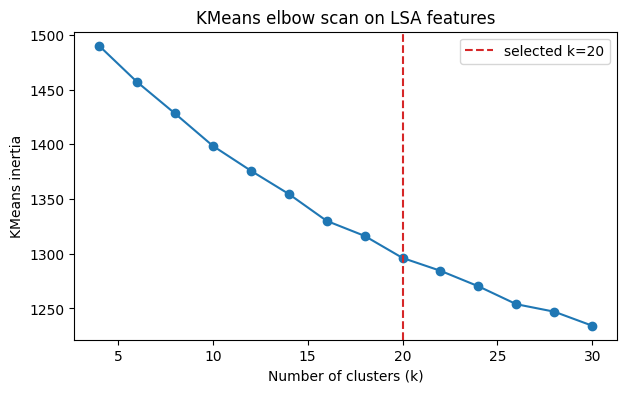

20

In [13]:
k_values = list(range(4, 31, 2))
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(lsa_embeddings)
    inertias.append(model.inertia_)

knee = KneeLocator(k_values, inertias, curve="convex", direction="decreasing")
best_k = int(knee.knee or 12)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, inertias, marker="o")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"selected k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("KMeans inertia")
ax.set_title("KMeans elbow scan on LSA features")
ax.legend()
plt.show()

best_k

In [14]:
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans_model.fit_predict(lsa_embeddings)
np.save(KMEANS_LABELS_CACHE, kmeans_labels)

ward_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
ward_labels = ward_model.fit_predict(lsa_embeddings)
np.save(WARD_LABELS_CACHE, ward_labels)

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, metric="euclidean")
hdbscan_labels = hdbscan_model.fit_predict(lsa_embeddings)
np.save(HDBSCAN_LABELS_CACHE, hdbscan_labels)

cluster_size_table(kmeans_labels)

,cluster,paper_count,share
0,2,185,0.100108
1,4,155,0.083874
2,3,143,0.077381
3,8,130,0.070346
4,13,128,0.069264
5,15,124,0.067100
6,0,118,0.063853
7,11,101,0.054654
8,5,93,0.050325
9,12,80,0.043290


In [15]:
metrics = []
for method, labels in [
    ("KMeans", kmeans_labels),
    ("Ward agglomerative", ward_labels),
    ("HDBSCAN", hdbscan_labels),
]:
    row = {"method": method}
    row.update(evaluate_labels(lsa_embeddings, labels))
    metrics.append(row)

clustering_results = pd.DataFrame(metrics).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
)

with CLUSTERING_CACHE.open("w") as handle:
    json.dump(clustering_results.to_dict(orient="records"), handle, indent=2)

clustering_results

,method,n_clusters,n_scored,outlier_fraction,silhouette,davies_bouldin,calinski_harabasz
2,HDBSCAN,2,269,0.854437,0.092882,4.232851,14.834460
0,KMeans,20,1848,0.000000,0.088108,3.700498,20.858453
1,Ward agglomerative,20,1848,0.000000,0.036092,4.009472,16.181321


In [16]:
hdbscan_cluster_sizes = cluster_size_table(hdbscan_labels)
hdbscan_cluster_sizes

,cluster,paper_count,share
0,-1,1579,0.854437
1,0,140,0.075758
2,1,129,0.069805


## Block 4 - Clustering on Sparse TF-IDF Features

This block repeats the clustering comparison on the original TF-IDF representation. The purpose is to separate two choices: the clustering algorithm and the document representation. If the same algorithm behaves differently on TF-IDF and on LSA, that difference is evidence that representation quality matters as much as the clustering method itself.

KMeans can work directly with sparse TF-IDF. Ward agglomerative clustering and HDBSCAN are run on a dense copy of the TF-IDF matrix here because their implementations expect dense numeric arrays for this setup. This is acceptable for the current dataset size, but it would not scale to a much larger arXiv corpus without dimensionality reduction or approximate methods.

In [17]:
TFIDF_CLUSTERING_CACHE = DATA_DIR / "tfidf_clustering_results.json"
TFIDF_KMEANS_LABELS_CACHE = DATA_DIR / "labels_kmeans_tfidf.npy"
TFIDF_WARD_LABELS_CACHE = DATA_DIR / "labels_ward_tfidf.npy"
TFIDF_HDBSCAN_LABELS_CACHE = DATA_DIR / "labels_hdbscan_tfidf.npy"

tfidf_matrix = sparse.load_npz(TFIDF_CACHE)
tfidf_dense = tfidf_matrix.toarray().astype(np.float32)

tfidf_matrix.shape, tfidf_dense.nbytes / 1024**2

((1848, 13487), 95.07742309570312)

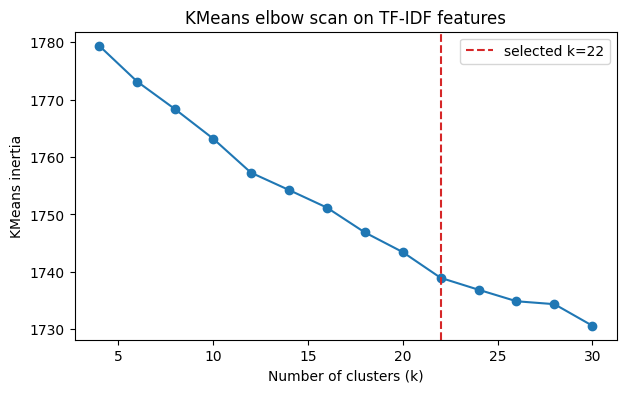

22

In [18]:
tfidf_inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    tfidf_inertias.append(model.inertia_)

tfidf_knee = KneeLocator(k_values, tfidf_inertias, curve="convex", direction="decreasing")
best_tfidf_k = int(tfidf_knee.knee or best_k)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, tfidf_inertias, marker="o")
ax.axvline(best_tfidf_k, color="tab:red", linestyle="--", label=f"selected k={best_tfidf_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("KMeans inertia")
ax.set_title("KMeans elbow scan on TF-IDF features")
ax.legend()
plt.show()

best_tfidf_k

In [19]:
tfidf_kmeans_model = KMeans(n_clusters=best_tfidf_k, random_state=42, n_init=20)
tfidf_kmeans_labels = tfidf_kmeans_model.fit_predict(tfidf_matrix)
np.save(TFIDF_KMEANS_LABELS_CACHE, tfidf_kmeans_labels)

tfidf_ward_model = AgglomerativeClustering(n_clusters=best_tfidf_k, linkage="ward")
tfidf_ward_labels = tfidf_ward_model.fit_predict(tfidf_dense)
np.save(TFIDF_WARD_LABELS_CACHE, tfidf_ward_labels)

tfidf_hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, metric="euclidean")
tfidf_hdbscan_labels = tfidf_hdbscan_model.fit_predict(tfidf_dense)
np.save(TFIDF_HDBSCAN_LABELS_CACHE, tfidf_hdbscan_labels)

cluster_size_table(tfidf_kmeans_labels)

,cluster,paper_count,share
0,18,139,0.075216
1,9,127,0.068723
2,8,115,0.062229
3,4,106,0.057359
4,16,104,0.056277
5,11,104,0.056277
6,15,103,0.055736
7,13,101,0.054654
8,3,100,0.054113
9,5,97,0.052489


In [20]:
tfidf_metrics = []
for method, labels in [
    ("KMeans", tfidf_kmeans_labels),
    ("Ward agglomerative", tfidf_ward_labels),
    ("HDBSCAN", tfidf_hdbscan_labels),
]:
    row = {"method": method, "representation": "TF-IDF"}
    row.update(evaluate_labels(tfidf_dense, labels))
    tfidf_metrics.append(row)

tfidf_clustering_results = pd.DataFrame(tfidf_metrics).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
)

with TFIDF_CLUSTERING_CACHE.open("w") as handle:
    json.dump(tfidf_clustering_results.to_dict(orient="records"), handle, indent=2)

tfidf_clustering_results

,method,representation,n_clusters,n_scored,outlier_fraction,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,TF-IDF,22,1848,0.0,0.007088,9.020637,2.871220
1,Ward agglomerative,TF-IDF,22,1848,0.0,0.003931,8.526994,2.947345
2,HDBSCAN,TF-IDF,0,0,1.0,NaN,NaN,NaN


In [21]:
lsa_results = clustering_results.assign(representation="LSA from TF-IDF")
combined_clustering_results = pd.concat(
    [lsa_results, tfidf_clustering_results],
    ignore_index=True,
    sort=False,
)[
    [
        "representation",
        "method",
        "n_clusters",
        "n_scored",
        "outlier_fraction",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
    ]
]

combined_clustering_results.sort_values("silhouette", ascending=False)

,representation,method,n_clusters,n_scored,outlier_fraction,silhouette,davies_bouldin,calinski_harabasz
0,LSA from TF-IDF,HDBSCAN,2,269,0.854437,0.092882,4.232851,14.834460
1,LSA from TF-IDF,KMeans,20,1848,0.000000,0.088108,3.700498,20.858453
2,LSA from TF-IDF,Ward agglomerative,20,1848,0.000000,0.036092,4.009472,16.181321
3,TF-IDF,KMeans,22,1848,0.000000,0.007088,9.020637,2.871220
4,TF-IDF,Ward agglomerative,22,1848,0.000000,0.003931,8.526994,2.947345
5,TF-IDF,HDBSCAN,0,0,1.000000,NaN,NaN,NaN


## Block 5 - Topic Interpretation

The clustering scores suggest that KMeans on the dense LSA representation is the most practical topic structure so far. This block interprets those clusters by combining three signals: cluster size, high-weight TF-IDF terms, and representative papers nearest to each KMeans centroid.

The resulting labels are keyword-based rather than hand-authored final titles. This keeps the notebook reproducible without requiring an external LLM call, while still making the clusters readable enough for analysis.

In [22]:
TOPIC_SUMMARY_CACHE = DATA_DIR / "topic_summary.csv"
PAPERS_WITH_TOPICS_CACHE = DATA_DIR / "papers_with_topics.parquet"
TOPIC_TERMS_CACHE = DATA_DIR / "topic_terms.csv"
TOPIC_TIMELINE_CACHE = DATA_DIR / "topic_timeline.csv"

papers = pd.read_parquet(PAPERS_CACHE)
tfidf_matrix = sparse.load_npz(TFIDF_CACHE)
lsa_embeddings = np.load(LSA_CACHE)
kmeans_labels = np.load(KMEANS_LABELS_CACHE)

with TFIDF_VECTORIZER_CACHE.open("rb") as handle:
    tfidf_vectorizer = pickle.load(handle)

papers = papers.copy()
papers["topic_id"] = kmeans_labels
papers["topic_id"].nunique(), papers.shape

(20, (1848, 13))

In [23]:
def top_terms_for_cluster(cluster_id: int, top_n: int = 10) -> list[tuple[str, float]]:
    cluster_mask = papers["topic_id"].to_numpy() == cluster_id
    mean_weights = np.asarray(tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
    top_indices = np.argsort(mean_weights)[-top_n:][::-1]
    terms = tfidf_vectorizer.get_feature_names_out()
    return [(terms[index], float(mean_weights[index])) for index in top_indices]


topic_term_rows = []
for cluster_id in sorted(papers["topic_id"].unique()):
    for rank, (term, weight) in enumerate(top_terms_for_cluster(cluster_id, top_n=12), start=1):
        topic_term_rows.append(
            {
                "topic_id": int(cluster_id),
                "rank": rank,
                "term": term,
                "mean_tfidf": weight,
            }
        )

topic_terms = pd.DataFrame(topic_term_rows)
topic_terms.to_csv(TOPIC_TERMS_CACHE, index=False)
topic_terms.head(24)

,topic_id,rank,term,mean_tfidf
0,0,1,model,0.033316
1,0,2,language,0.032196
2,0,3,models,0.031123
3,0,4,training,0.028104
4,0,5,token,0.027484
5,0,6,large,0.026201
6,0,7,llms,0.025396
7,0,8,language models,0.025243
8,0,9,inference,0.025116
9,0,10,large language,0.023075


In [24]:
def make_keyword_label(cluster_id: int, n_terms: int = 4) -> str:
    terms = topic_terms.loc[topic_terms["topic_id"] == cluster_id, "term"].head(n_terms)
    return ", ".join(terms)


centroids = kmeans_model.cluster_centers_
similarity_to_centroid = np.sum(lsa_embeddings * centroids[kmeans_labels], axis=1)
papers["centroid_similarity"] = similarity_to_centroid
papers["topic_label"] = papers["topic_id"].map(
    {cluster_id: make_keyword_label(cluster_id) for cluster_id in sorted(papers["topic_id"].unique())}
)

representatives = (
    papers.sort_values(["topic_id", "centroid_similarity"], ascending=[True, False])
    .groupby("topic_id")
    .head(3)
    .loc[:, ["topic_id", "topic_label", "title", "primary_category", "published", "centroid_similarity"]]
)

representatives.head(12)

,topic_id,topic_label,title,primary_category,published,centroid_similarity
954,0,"model, language, models, training",ParaScopes: What do Language Models Activations Encode About Future Text?,cs.CL,2025-10-31 18:36:10+00:00,0.296670
429,0,"model, language, models, training",Distribution-Aware Companding Quantization of Large Language Models,cs.CL,2026-02-27 23:00:54+00:00,0.285815
52,0,"model, language, models, training",DPN-LE: Dual Personality Neuron Localization and Editing for Large Language Models,cs.CL,2026-04-30 14:31:46+00:00,0.279748
1822,1,"federated, federated learning, fl, privacy",PSI-PFL: Population Stability Index for Client Selection in non-IID Personalized Federated Learning,cs.LG,2025-05-31 07:41:42+00:00,0.650988
1838,1,"federated, federated learning, fl, privacy",Blockchain-Enabled Privacy-Preserving Second-Order Federated Edge Learning in Personalized Healthcare,cs.LG,2025-05-31 06:41:04+00:00,0.628938
1726,1,"federated, federated learning, fl, privacy",Optimized Local Updates in Federated Learning via Reinforcement Learning,cs.LG,2025-05-31 19:32:42+00:00,0.603643
1095,2,"machine learning, machine, data, learning",A Framework for Selection of Machine Learning Algorithms Based on Performance Metrices and Akaike Information Criter...,cs.LG,2025-09-30 22:27:34+00:00,0.317196
1376,2,"machine learning, machine, data, learning",A Novel Method to Determine Total Oxidant Concentration Produced by Non-Thermal Plasma Based on Image Processing and...,eess.IV,2025-08-30 12:28:52+00:00,0.315173
1630,2,"machine learning, machine, data, learning",When Plants Respond: Electrophysiology and Machine Learning for Green Monitoring Systems,cs.LG,2025-06-30 14:04:31+00:00,0.304541
884,3,"llms, language, language models, llm",Sycophancy Claims about Language Models: The Missing Human-in-the-Loop,cs.CL,2025-11-29 22:40:53+00:00,0.376196


In [25]:
topic_summary = (
    papers.groupby(["topic_id", "topic_label"])
    .agg(
        paper_count=("arxiv_id", "count"),
        median_abstract_words=("abstract_length", "median"),
        first_published=("published", "min"),
        last_published=("published", "max"),
    )
    .reset_index()
    .sort_values("paper_count", ascending=False)
)
topic_summary["paper_share"] = topic_summary["paper_count"] / len(papers)

topic_summary.to_csv(TOPIC_SUMMARY_CACHE, index=False)
papers.to_parquet(PAPERS_WITH_TOPICS_CACHE, index=False)

topic_summary.head(20)

,topic_id,topic_label,paper_count,median_abstract_words,first_published,last_published,paper_share
2,2,"machine learning, machine, data, learning",185,170.0,2025-05-31 05:54:49+00:00,2026-04-30 17:55:28+00:00,0.100108
4,4,"learning, transformer, attention, model",155,177.0,2025-05-31 08:09:54+00:00,2026-04-30 17:12:31+00:00,0.083874
3,3,"llms, language, language models, llm",143,172.0,2025-05-31 06:44:48+00:00,2026-04-30 17:33:58+00:00,0.077381
8,8,"agent, agents, ai, llm",130,177.5,2025-05-31 12:57:56+00:00,2026-04-30 17:58:02+00:00,0.070346
13,13,"optimization, algorithm, algorithms, problem",128,173.0,2025-05-31 05:35:45+00:00,2026-04-30 17:59:07+00:00,0.069264
15,15,"neural, networks, neural networks, network",124,170.0,2025-05-31 04:48:53+00:00,2026-04-30 17:57:22+00:00,0.067100
0,0,"model, language, models, training",118,167.0,2025-05-31 04:51:12+00:00,2026-04-30 17:30:15+00:00,0.063853
11,11,"github, https, github com, com",101,176.0,2025-05-31 05:59:56+00:00,2026-04-30 17:43:07+00:00,0.054654
5,5,"diffusion, generative, generation, diffusion models",93,169.0,2025-05-31 06:10:10+00:00,2026-04-30 17:53:03+00:00,0.050325
12,12,"reinforcement learning, reinforcement, rl, learning",80,185.0,2025-05-31 07:38:41+00:00,2026-04-30 15:30:47+00:00,0.043290


In [26]:
topic_timeline = (
    papers.groupby(["published_month", "topic_id", "topic_label"])
    .size()
    .rename("paper_count")
    .reset_index()
)
topic_timeline["month_total"] = topic_timeline.groupby("published_month")["paper_count"].transform("sum")
topic_timeline["month_share"] = topic_timeline["paper_count"] / topic_timeline["month_total"]
topic_timeline.to_csv(TOPIC_TIMELINE_CACHE, index=False)

largest_topics = topic_summary.head(6)["topic_id"].tolist()
topic_timeline[topic_timeline["topic_id"].isin(largest_topics)].tail(18)

,published_month,topic_id,topic_label,paper_count,month_total,month_share
182,2026-02,2,"machine learning, machine, data, learning",8,154,0.051948
183,2026-02,3,"llms, language, language models, llm",9,154,0.058442
184,2026-02,4,"learning, transformer, attention, model",20,154,0.129870
188,2026-02,8,"agent, agents, ai, llm",13,154,0.084416
193,2026-02,13,"optimization, algorithm, algorithms, problem",9,154,0.058442
195,2026-02,15,"neural, networks, neural networks, network",9,154,0.058442
202,2026-03,2,"machine learning, machine, data, learning",17,154,0.110390
203,2026-03,3,"llms, language, language models, llm",12,154,0.077922
204,2026-03,4,"learning, transformer, attention, model",15,154,0.097403
208,2026-03,8,"agent, agents, ai, llm",18,154,0.116883


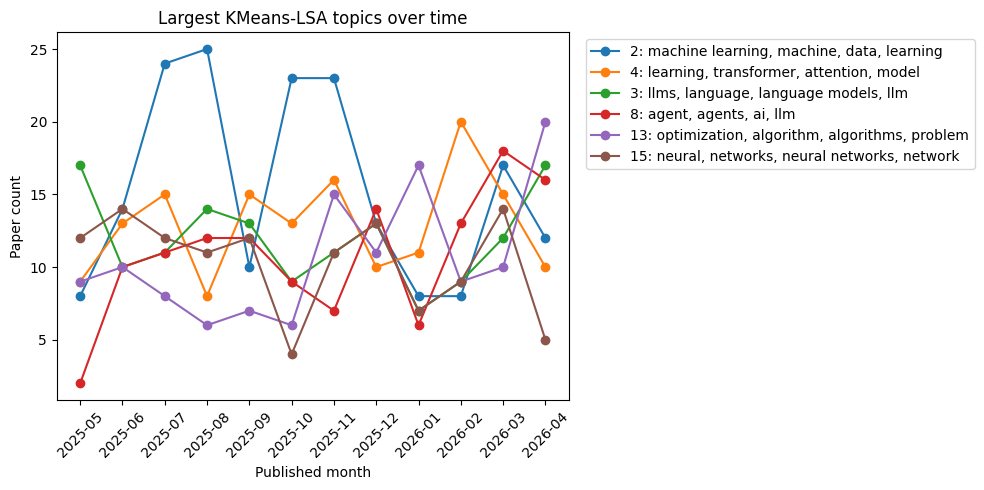

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
for topic_id in largest_topics:
    topic_frame = topic_timeline[topic_timeline["topic_id"] == topic_id]
    label = topic_summary.loc[topic_summary["topic_id"] == topic_id, "topic_label"].iloc[0]
    ax.plot(topic_frame["published_month"], topic_frame["paper_count"], marker="o", label=f"{topic_id}: {label}")

ax.set_title("Largest KMeans-LSA topics over time")
ax.set_xlabel("Published month")
ax.set_ylabel("Paper count")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()